# EDA (Exploratory Data Analysis): 탐색적 데이터 분석
---

# 1. 라이브러리 import

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 문제 해결
plt.rcParams['axes.unicode_minus'] = False # - 표시 문제 해결

print("라이브러리 import 완료")

라이브러리 import 완료


# 2. 데이터 로드

In [2]:
# 데이터 로드
# base_dir = os.path.dirname(os.path.abspath(__file__)) # py file 에서 절대 경로를 얻는 코드
base_dir = os.getcwd()
file_path = os.path.join(base_dir, "..", "data", "synthetic_customer_churn_100k.csv")
df = pd.read_csv(file_path, skipinitialspace=True)
df.shape

(100000, 9)

## 3. 기본 정보 확인

In [3]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No
...,...,...,...,...,...,...,...,...,...
99995,99996,31,Male,49,26.07,Month-to-month,Electronic check,1220.50,No
99996,99997,64,Female,44,123.22,Month-to-month,Mailed check,5384.38,No
99997,99998,48,Other,32,75.37,Month-to-month,Credit card,2372.33,Yes
99998,99999,42,Female,60,114.00,Month-to-month,Mailed check,6826.55,No


In [4]:
# 데이터 타입 및 결측치 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 9.9 MB


In [5]:
# 수치형 기술통계량
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [6]:
# 범주형 기술통계량
df.describe(include='object')

C:\Users\Playdata\AppData\Local\Temp\ipykernel_11212\2421657943.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Contract,PaymentMethod,Churn
count,100000,100000,100000,100000
unique,3,3,4,2
top,Female,Month-to-month,Electronic check,No
freq,48256,54915,34892,66856


# 4. 결측치 확인

In [7]:
# 결측치 개수
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    '결측치 개수': missing,
    '결측치 비율(%)': missing_pct
})
missing_df[missing_df['결측치 개수'] > 0] # 결측치가 있는 컬럼만 필터링하는 코드

,결측치 개수,결측치 비율(%)


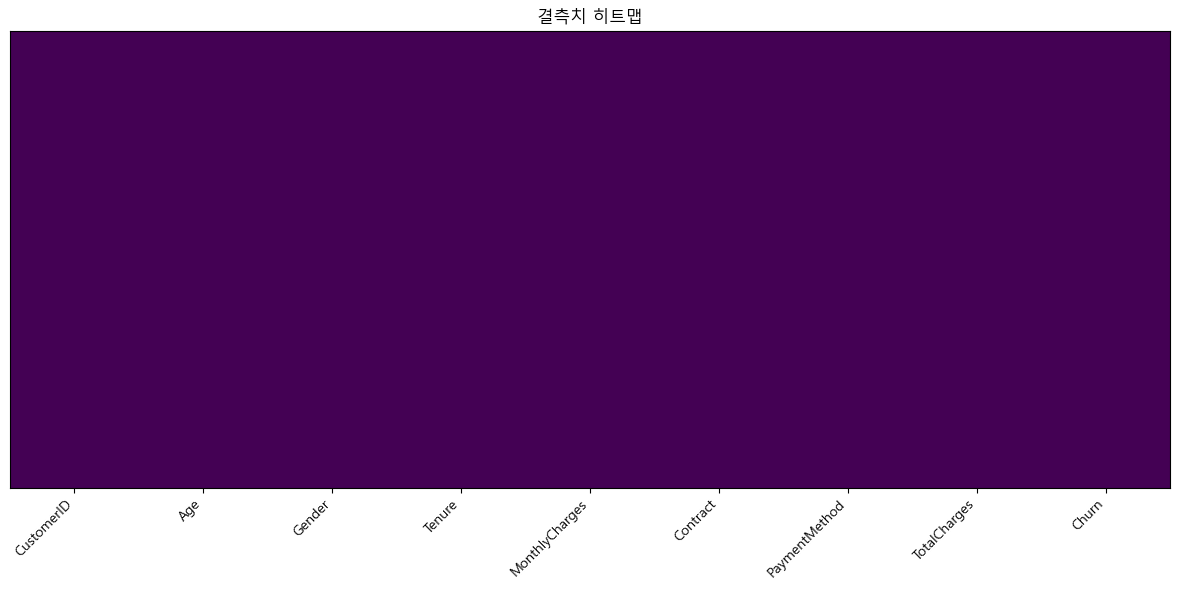

In [8]:
# 결측치 시각화
# sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
# plt.title('결측치 히트맵')
# plt.tight_layout()
# plt.show()

plt.imshow(df.isnull(), aspect='auto', cmap='viridis')
plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha='right')
plt.yticks([])  # y축 눈금 숨기기
plt.title('결측치 히트맵')
plt.tight_layout()
plt.show()

In [9]:
df2 = df.copy()
df2.loc[0, 'Age'] = np.nan
df2

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,NaN,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69.0,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46.0,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32.0,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60.0,Female,54,130.98,Month-to-month,Credit card,7081.28,No
...,...,...,...,...,...,...,...,...,...
99995,99996,31.0,Male,49,26.07,Month-to-month,Electronic check,1220.50,No
99996,99997,64.0,Female,44,123.22,Month-to-month,Mailed check,5384.38,No
99997,99998,48.0,Other,32,75.37,Month-to-month,Credit card,2372.33,Yes
99998,99999,42.0,Female,60,114.00,Month-to-month,Mailed check,6826.55,No


In [10]:
# 결측치 개수
missing = df2.isnull().sum()
missing_pct = (df2.isnull().sum() / len(df2)) * 100

missing_df2 = pd.DataFrame({
    '결측치 개수': missing,
    '결측치 비율(%)': missing_pct
})
missing_df2

,결측치 개수,결측치 비율(%)
CustomerID,0,0.000
Age,1,0.001
Gender,0,0.000
Tenure,0,0.000
MonthlyCharges,0,0.000
Contract,0,0.000
PaymentMethod,0,0.000
TotalCharges,0,0.000
Churn,0,0.000


In [11]:
missing_df2

,결측치 개수,결측치 비율(%)
CustomerID,0,0.000
Age,1,0.001
Gender,0,0.000
Tenure,0,0.000
MonthlyCharges,0,0.000
Contract,0,0.000
PaymentMethod,0,0.000
TotalCharges,0,0.000
Churn,0,0.000


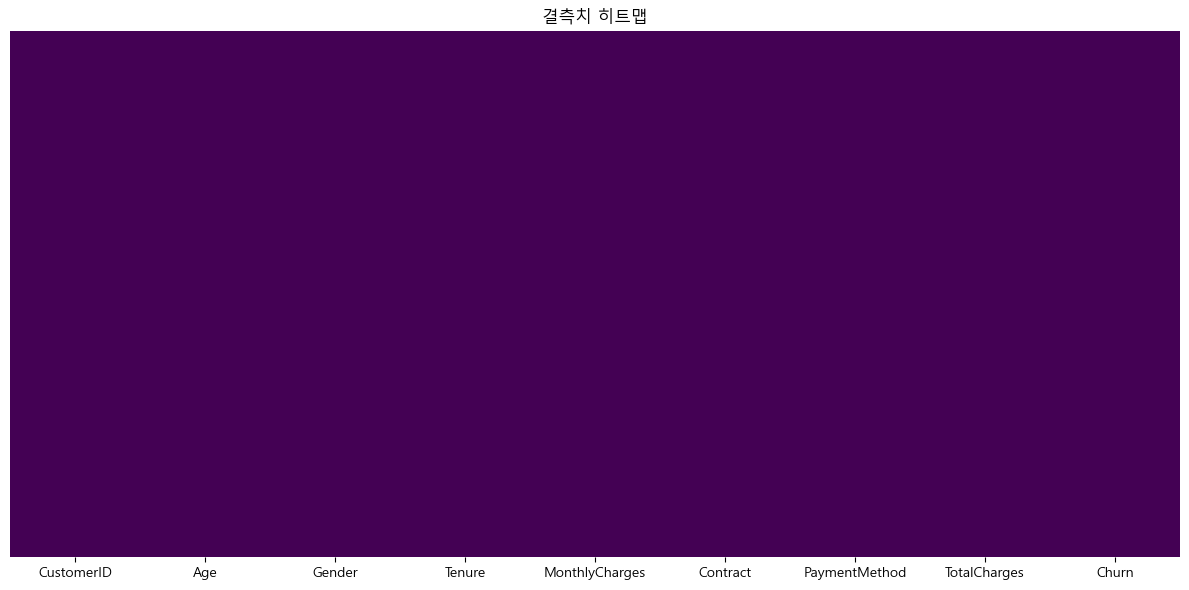

In [12]:
# 결측치 시각화
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('결측치 히트맵')
plt.tight_layout()
plt.show()

# plt.imshow(df.isnull(), aspect='auto', cmap='viridis') # matplotlib 그래프
# plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha='right')
# plt.yticks([])  # y축 눈금 숨기기
# plt.title('결측치 히트맵')
# plt.tight_layout()
# plt.show()


# 5. Target 변수 분석

In [13]:
# Target 분포 확인
print(df['Churn'].value_counts())
print(f'\nChurn 비율:\n{df["Churn"].value_counts(normalize=True) * 100}')

Churn
No     66856
Yes    33144
Name: count, dtype: int64

Churn 비율:
Churn
No     66.856
Yes    33.144
Name: proportion, dtype: float64


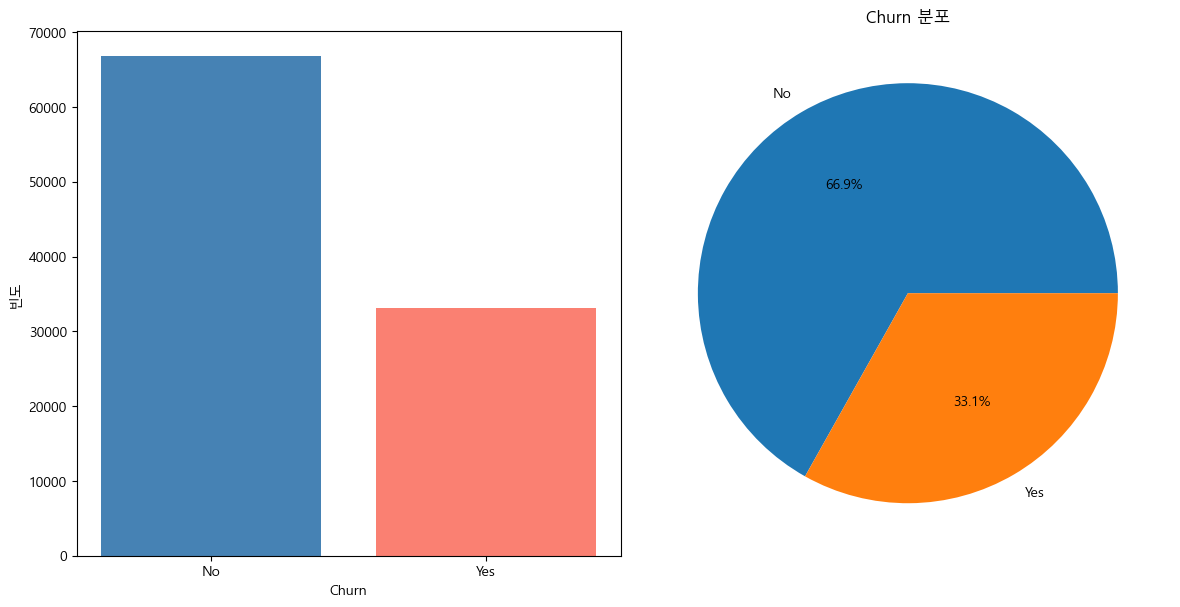

-> 저장 완료: EDA_plots_Lee\01_target.png


In [14]:
# Target 분포 시각화
fig = plt.figure()

# 막대 그래프
ax1 = fig.add_subplot(1,2,1)
churn_counts = df['Churn'].value_counts()
ax1.bar(churn_counts.index, churn_counts.values, color=['steelblue', 'salmon'])
# df['Churn'].value_counts().plot(kind='bar', ax=ax1, color=['steelblue', 'salmon'])
ax1.set_xlabel('Churn')
ax1.set_ylabel('빈도')

# 파이 차트
ax2 = fig.add_subplot(1, 2, 2)
churn_counts = df['Churn'].value_counts()
ax2.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%')
# df['Churn'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Churn 분포')

plt.tight_layout()

# 파일로 저장 후 닫기
output_dir = 'EDA_plots_Lee'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, '01_target.png')
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"-> 저장 완료: {file_path}")

# 6. 수치형 변수 분석

In [15]:
# 수치형 컬럼 선택
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['Gender', 'Contract', 'PaymentMethod', 'Churn']
print(f'수치형 컬럼: {num_cols}')
print(f'수치형 컬럼: {cat_cols}')

수치형 컬럼: ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
수치형 컬럼: ['Gender', 'Contract', 'PaymentMethod', 'Churn']


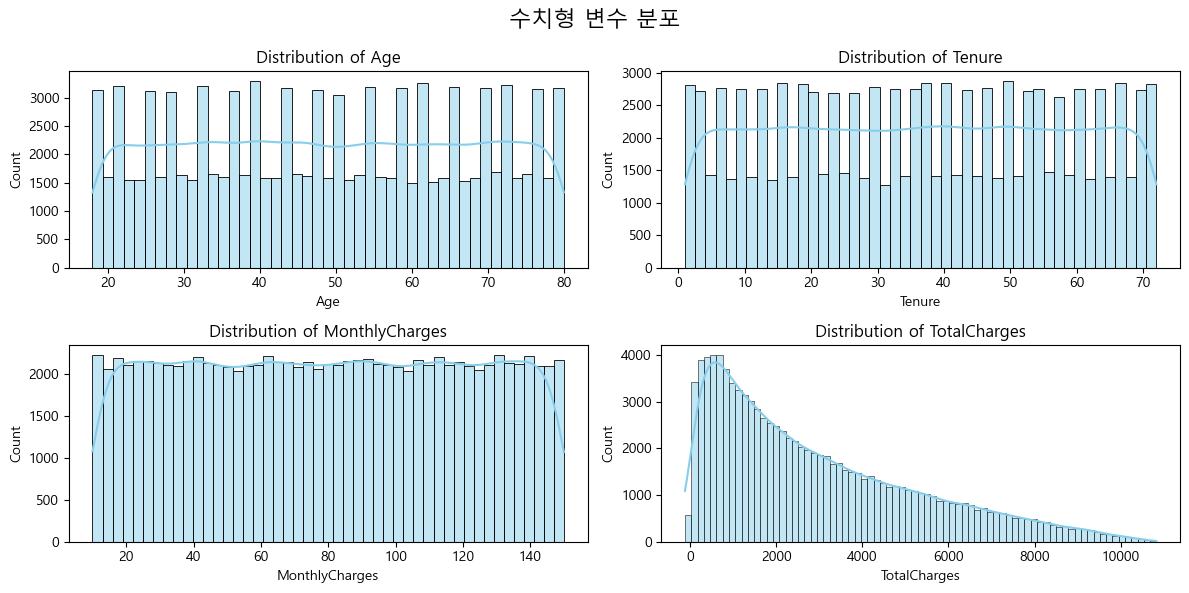

-> 저장 완료: EDA_plots_Lee\02_neumeric.png


In [30]:
# 수치형 변수 

# 막대그래프
# df[num_cols].hist(bins=30, color=['skyblue'])
# plt.suptitle('수치형 변수 분포', fontsize=16)

# 막대 그래프
# fig = plt.figure()

# ax1 = fig.add_subplot(2,2,1)
# ax1.hist(df["Age"], bins=30, color=['skyblue'])
# ax1.set_xlabel('Age')
# ax1.set_ylabel('Year')

# ax2 = fig.add_subplot(2,2,2)
# ax2.hist(df["Tenure"], bins=30, color=['skyblue'])
# ax2.set_xlabel('Tenure')
# ax2.set_ylabel('Month')

# ax3 = fig.add_subplot(2,2,3)
# ax3.hist(df["MonthlyCharges"], bins=30, color=['skyblue'])
# ax3.set_xlabel('MonthlyCharges')
# ax3.set_ylabel('$')

# ax4 = fig.add_subplot(2,2,4)
# ax4.hist(df["TotalCharges"], bins=30, color=['skyblue'])
# ax4.set_xlabel('TotalCharges')
# ax4.set_ylabel('$')

# plt.suptitle('수치형 변수 분포', fontsize=16)
# plt.tight_layout()

# 막대 그래프
# fig, axes = plt.subplots(2, 2)
# plt.suptitle('수치형 변수 분포', fontsize=16)

# axes[0, 0].hist(df['Age'], bins=30, color=['skyblue'])
# axes[0, 0].set_xlabel('Age')
# axes[0, 0].set_ylabel('Year')

# axes[0, 1].hist(df["Tenure"], bins=30, color=['skyblue'])
# axes[0, 1].set_xlabel("Tenure")
# axes[0, 1].set_ylabel('Month')

# axes[1, 0].hist(df["MonthlyCharges"], bins=30, color=['skyblue'])
# axes[1, 0].set_xlabel("MonthlyCharges")
# axes[1, 0].set_ylabel("$")

# axes[1, 1].hist(df["MonthlyCharges"], bins=30, color=['skyblue'])
# axes[1, 1].set_xlabel("MonthlyCharges")
# axes[1, 1].set_ylabel('$')

# plt.suptitle('수치형 변수 분포', fontsize=16)
# plt.tight_layout()


# --------------------------------------------------
#  [Plot 2] 수치형 변수들의 분포 (Histograms)
# --------------------------------------------------
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle('수치형 변수 분포', fontsize=16)
plt.tight_layout()

# 파일로 저장 후 닫기
output_dir = 'EDA_plots_Lee'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, '02_neumeric.png')
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"-> 저장 완료: {file_path}")

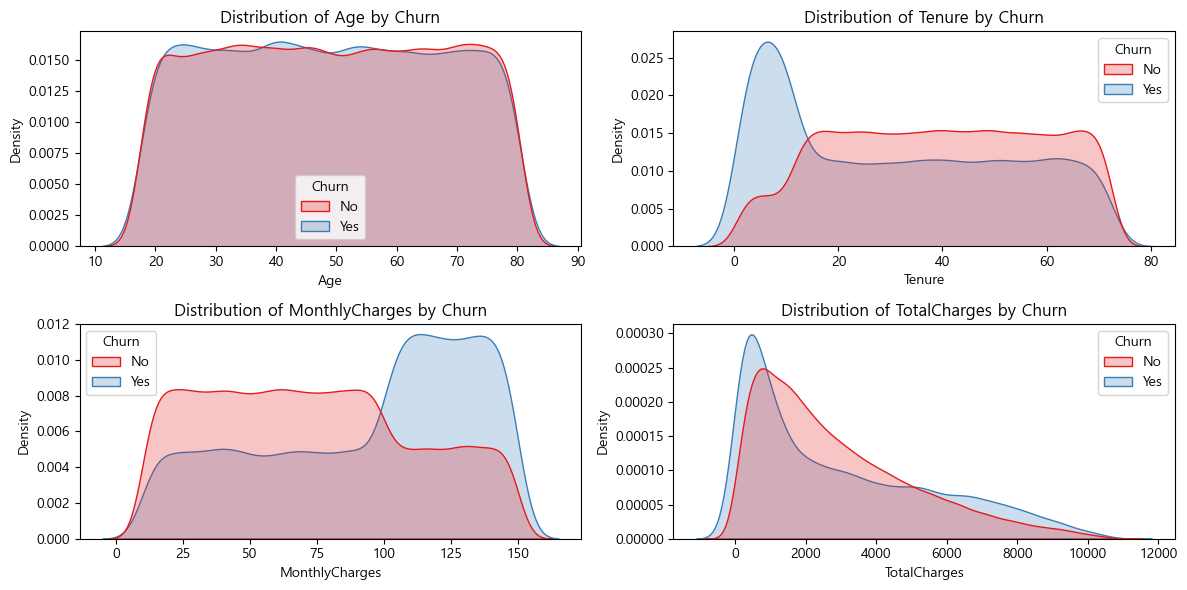

-> 저장 완료: EDA_plots_Lee\02-1_neumeric.png


In [17]:
# 수치형 변수들이 이탈 여부에 따른 분포 차이
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribution of {col} by Churn')

plt.tight_layout()

# 파일로 저장 후 닫기
output_dir = 'EDA_plots_Lee'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, '02-1_neumeric.png')
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"-> 저장 완료: {file_path}")

In [18]:
# 박스플롯 (이상치 확인)
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(15, 5))
for i, col in enumerate(numeric_columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('수치형 변수 박스플롯', fontsize=16)
plt.tight_layout()
plt.show()

NameError: name 'numeric_columns' is not defined

# 7. 범주형 변수 분포

In [ ]:
# 범주형 컬럼 선택
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print(f'범주형 컬럼: {categorical_columns}')

범주형 컬럼: ['Gender', 'Contract', 'PaymentMethod', 'Churn']


C:\Users\Playdata\AppData\Local\Temp\ipykernel_42948\1326219895.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns.tolist()


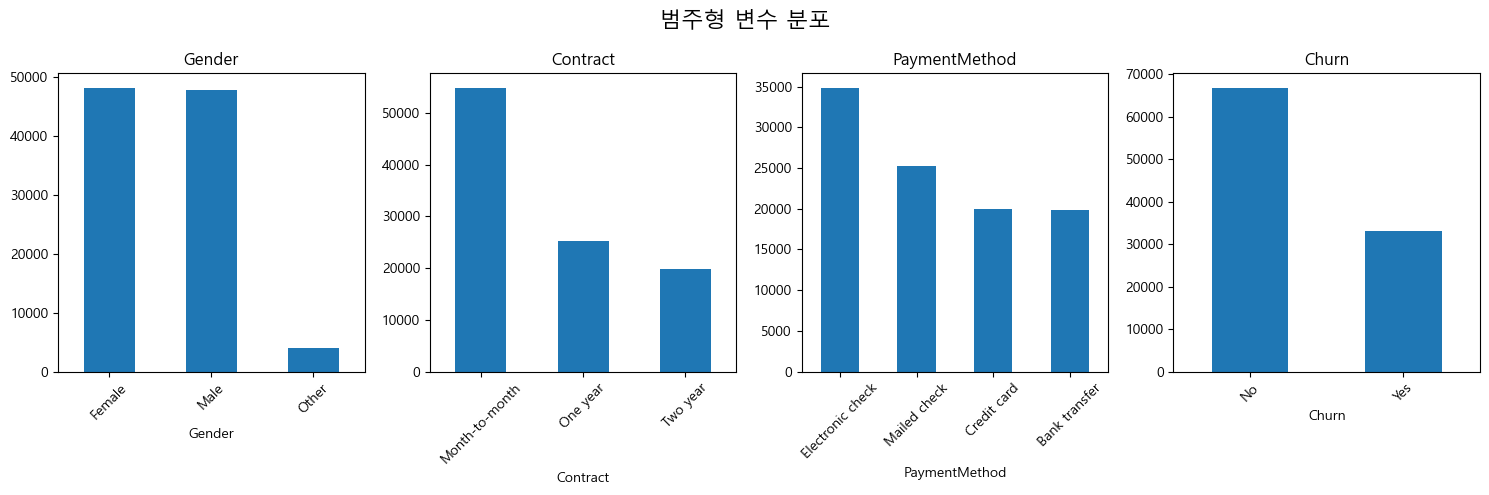

In [ ]:
# 범주형 변수 분포 시각화
fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 5))
for i, col in enumerate(categorical_columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('범주형 변수 분포', fontsize=16)
plt.tight_layout()
plt.show()

# 8. Target과 변수 관계 분석

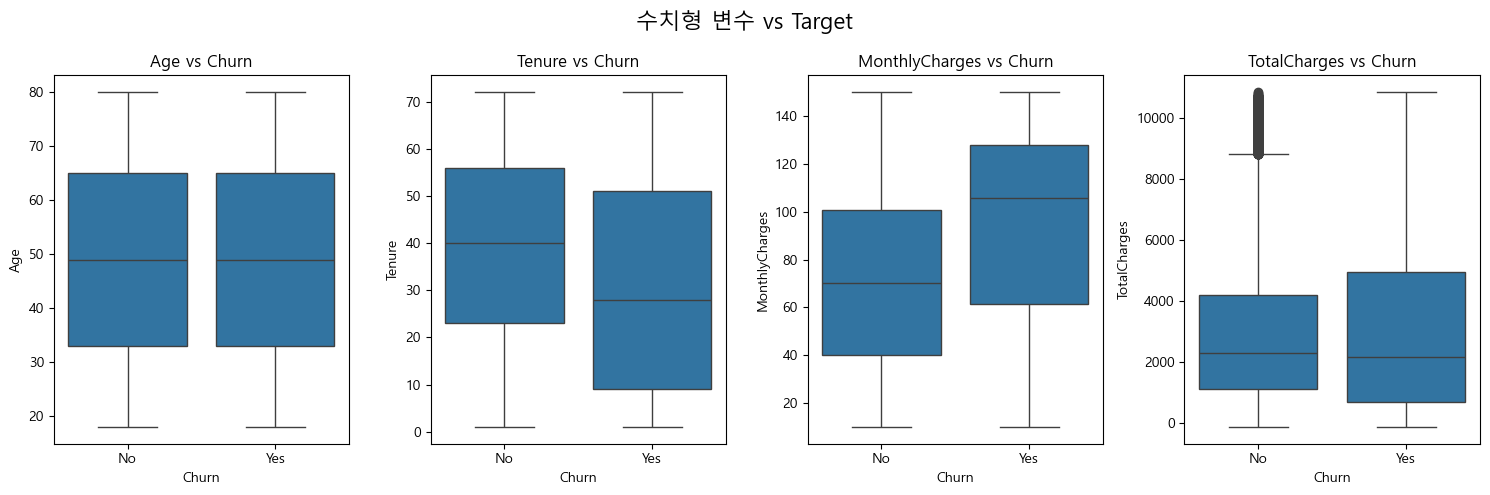

In [ ]:
# 수치형 변수 vs Target
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(15, 5))
for i, col in enumerate(numeric_columns):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.suptitle('수치형 변수 vs Target', fontsize=16)
plt.tight_layout()
plt.show()

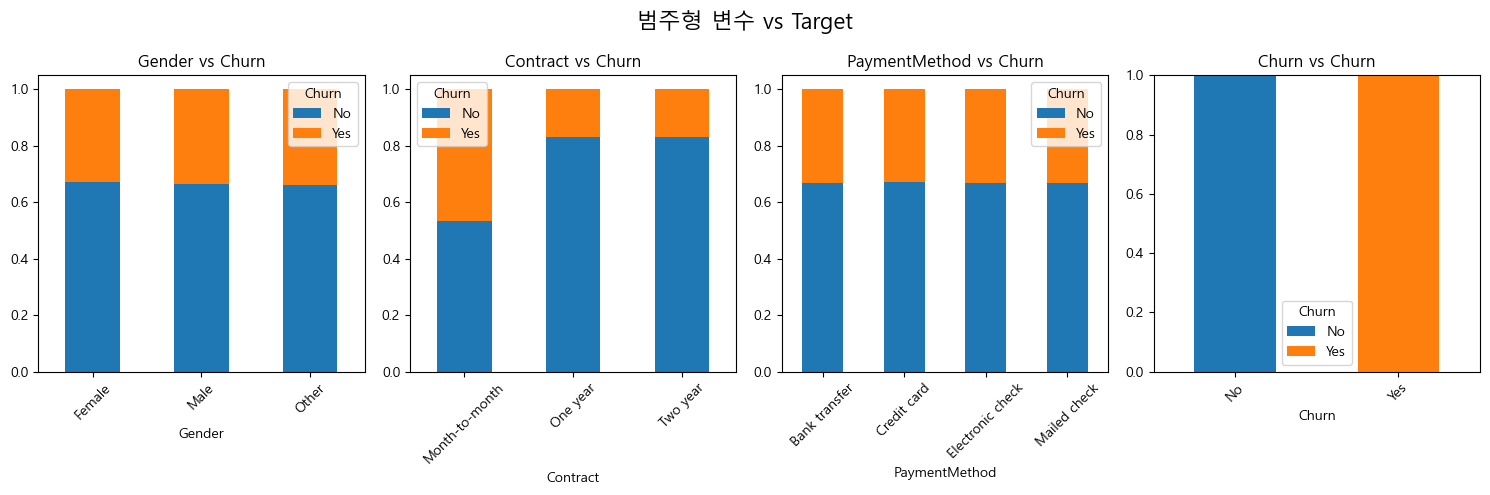

In [ ]:
# 범주형 변수 vs Target
fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 5))
for i, col in enumerate(categorical_columns):
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(
        kind='bar', ax=axes[i], stacked=True
    )
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('범주형 변수 vs Target', fontsize=16)
plt.tight_layout()
plt.show()

# 9. 상관관계 분석

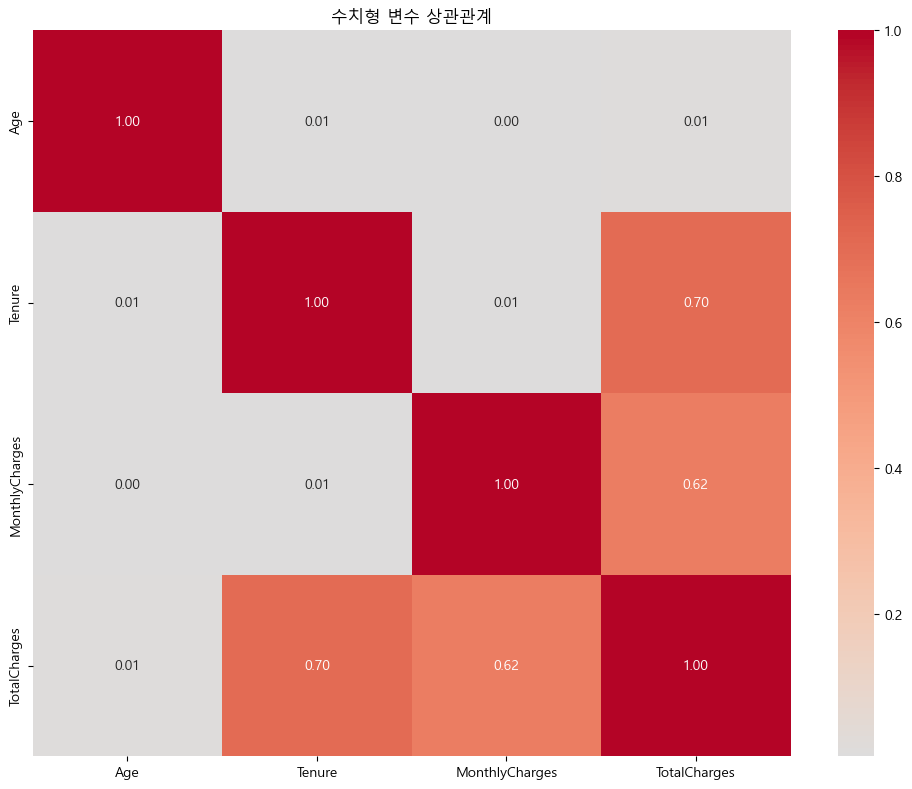

In [ ]:
# 상관관계 히트맵
plt.figure(figsize=(10, 8))
corr = df[numeric_columns].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 변수 상관관계')
plt.tight_layout()
plt.show()

# 10. 이상치 확인

In [ ]:
# 음수값 확인
for col in numeric_columns:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'{col}: 음수값 {neg_count}개')

TotalCharges: 음수값 265개


In [ ]:
# IQR 기반 이상치 확인
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: 이상치 {outliers}개 ({outliers/len(df)*100:.2f}%)')

Age: 이상치 0개 (0.00%)
Tenure: 이상치 0개 (0.00%)
MonthlyCharges: 이상치 0개 (0.00%)
TotalCharges: 이상치 841개 (0.84%)


# 11. EDA 요약

In [ ]:
print('=' * 50)
print('EDA 요약')
print('=' * 50)
print(f'데이터 크기       : {df.shape}')
print(f'수치형 컬럼       : {numeric_columns}')
print(f'범주형 컬럼       : {categorical_columns}')
print(f'결측치 존재 여부  : {df.isnull().any().any()}')
print(f'Target 분포       :\n{df["Churn"].value_counts()}')
print('=' * 50)

EDA 요약
데이터 크기       : (100000, 9)
수치형 컬럼       : ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
범주형 컬럼       : ['Gender', 'Contract', 'PaymentMethod', 'Churn']
결측치 존재 여부  : False
Target 분포       :
Churn
No     66856
Yes    33144
Name: count, dtype: int64
